# 单表格模型预测

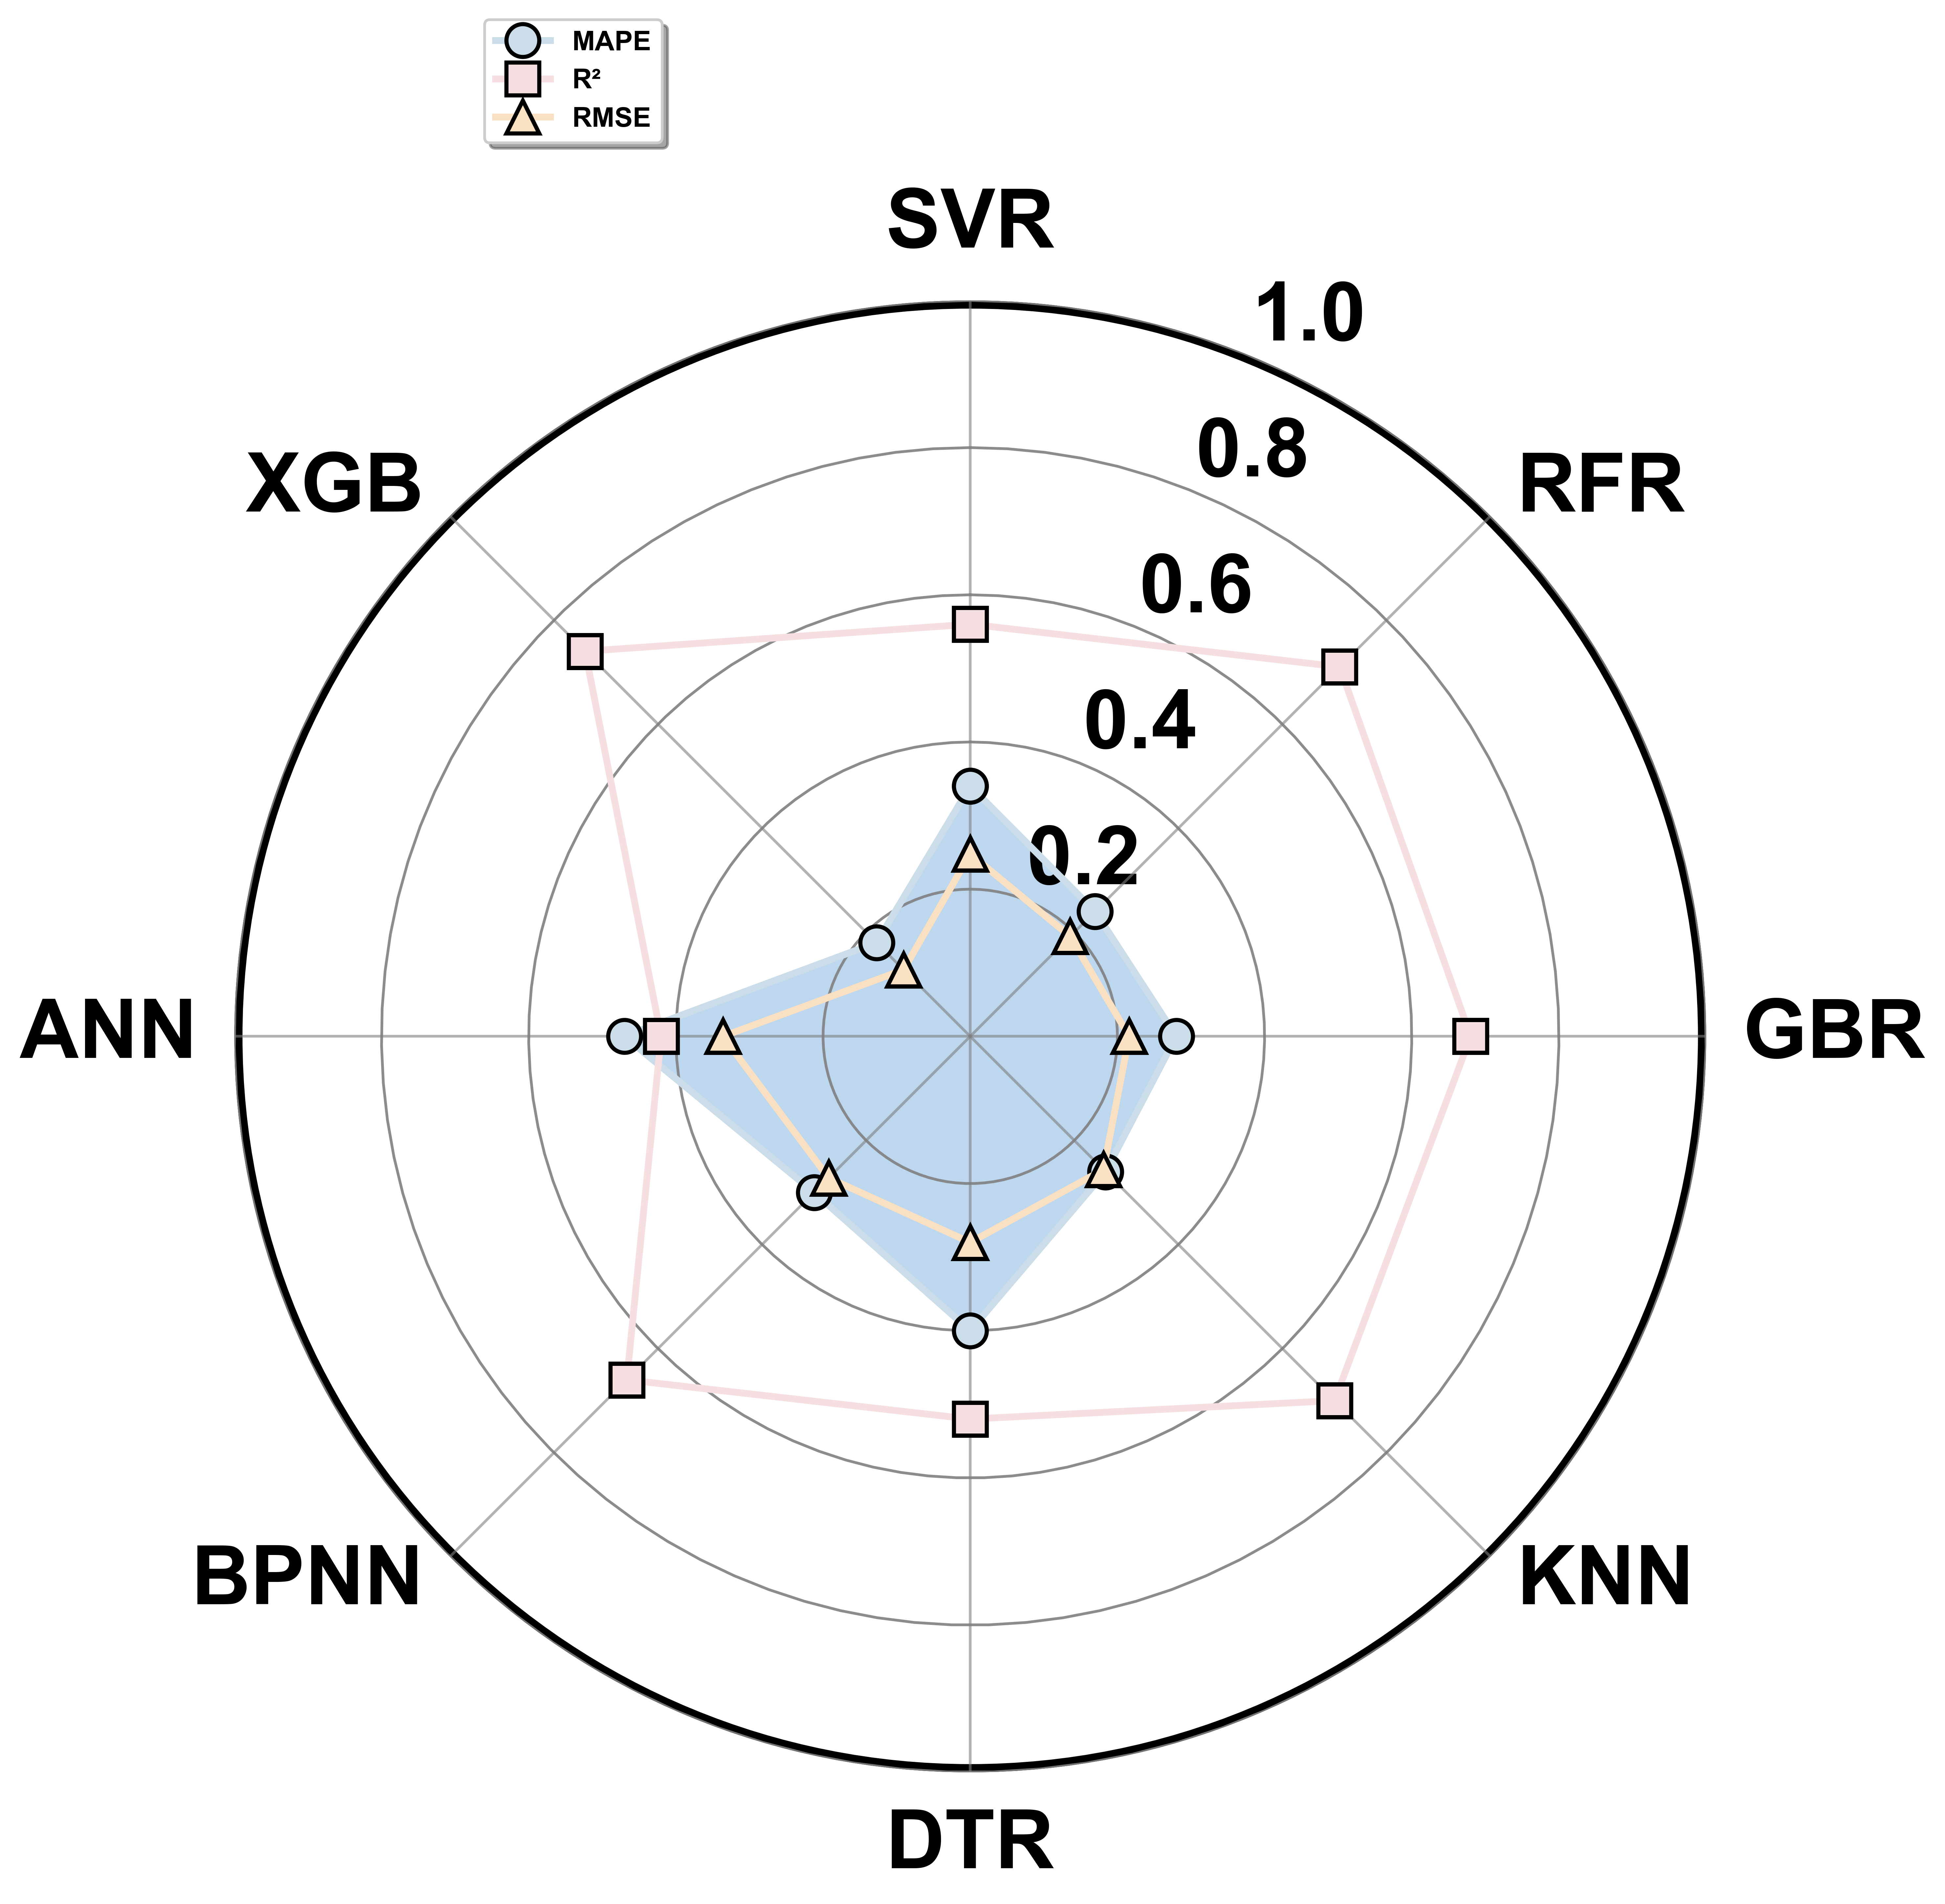

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm

# 设置字体为Times New Roman（新罗马）
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.unicode_minus'] = False

def create_final_radar():
    """创建最终完整版本的雷达图"""
    # 定义8个维度标签
    labels = ['SVR', 'RFR', 'GBR', 'KNN', 'DTR', 'BPNN', 'ANN', 'XGB']
    
    # 定义MAPE数据值
    mape_values = [0.34, 0.24, 0.28, 0.26, 0.40, 0.30, 0.47, 0.18]
    
    # 定义R2数据值
    r2_values = [0.56, 0.71, 0.68, 0.70, 0.52, 0.66, 0.42, 0.74]
    
    # 定义RMSE数据值
    rmse_values = [0.31, 0.24, 0.27, 0.32, 0.35, 0.34, 0.42, 0.16]
    
    # 将R2值缩放到合适的显示范围
    r2_values_scaled = [v * 1.0 for v in r2_values]
    
    # 缩放RMSE值
    rmse_values_scaled = [v * 0.8 for v in rmse_values]
    
    # 计算角度
    N = len(labels)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    
    # 闭合图形
    angles += angles[:1]
    mape_values += mape_values[:1]
    r2_values_scaled += r2_values_scaled[:1]
    rmse_values_scaled += rmse_values_scaled[:1]
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(10, 10), dpi=600, subplot_kw=dict(projection='polar'))
    
    # 设置角度
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    # 设置范围
    ax.set_ylim(0, 1.0)
    
    # 绘制网格圆圈
    grid_levels = [0.2, 0.4, 0.6, 0.8, 1.0]
    for level in grid_levels:
        circle_angles = np.linspace(0, 2*np.pi, 100)
        ax.plot(circle_angles, [level]*100, color='gray', linewidth=1.0, alpha=0.9)
    
    # 绘制径向线
    for angle in angles[:-1]:
        ax.plot([angle, angle], [0, 1.0], color='gray', linewidth=1.0, alpha=0.6)
    
    # 绘制外边框 - 黑色粗边框
    border_circle = plt.Circle((0, 0), 1.0, transform=ax.transData._b,
                            fill=False, edgecolor='black', linewidth=6.0)
    ax.add_patch(border_circle)
    
    # 绘制数据区域 - MAPE
    ax.fill(angles, mape_values, color='#5B9BD5', alpha=0.4)
    mape_line = ax.plot(angles, mape_values, color='#cbdde9', linewidth=2.5, marker='o',
            markersize=12, markerfacecolor='#cbdde9', markeredgecolor='black',
            markeredgewidth=1.5, label='MAPE')
    
    # 绘制R2数据
    r2_line = ax.plot(angles, r2_values_scaled, color='#f5dfe1', linewidth=2.5, marker='s',
            markersize=12, markerfacecolor='#f5dfe1', markeredgecolor='black',
            markeredgewidth=1.5, label='R²')
    
    # 绘制RMSE数据
    rmse_line = ax.plot(angles, rmse_values_scaled, color='#f9e0c2', linewidth=2.5, marker='^',
            markersize=12, markerfacecolor='#f9e0c2', markeredgecolor='black',
            markeredgewidth=1.5, label='RMSE')
    
    # 方法1: 使用set_rlabel_position调整径向标签位置，避免与轴标签重叠
    #ax.set_rlabel_position(55.5)  # 调整径向刻度标签的角度位置
    
    # 方法2: 自定义标签位置 - 设置标签距离中心的位置
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=30, fontweight='bold', fontfamily='Arial')
    
    # 方法3: 手动设置每个标签的位置（更精确的控制）
    # 如果需要更精确控制每个标签，可以用以下代码替换上面的set_xticklabels

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])  # 先清空默认标签
    
    # 自定义每个标签的位置
    label_distance = 1.05  # 标签距离中心的距离，可以调整这个值
    for angle, label in zip(angles[:-1], labels):
        # 计算标签位置
        x = angle
        y = label_distance
        
        # 根据角度调整文本对齐方式
        ha = 'center'
        va = 'center'
        
        if angle == 0:
            ha = 'center'
            va = 'bottom'
        elif 0 < angle < np.pi:
            ha = 'left'
            va = 'center'
        elif angle == np.pi:
            ha = 'center'
            va = 'top'
        else:
            ha = 'right'
            va = 'center'
        
        ax.text(x, y, label, fontsize=30, fontweight='bold', 
                fontfamily='Arial', ha=ha, va=va)
    
    # 设置径向刻度标签 - 加粗，增大字体大小到14
    ax.set_yticks(grid_levels)
    ax.set_yticklabels([f'{v:.1f}' for v in grid_levels],
                      fontsize=30, fontweight='bold', fontfamily='Arial')
    
    # 添加图例 - 使用实际的线条而不是补丁
    ax.legend(loc='upper right', bbox_to_anchor=(0.3, 1.2),
              fontsize=60, frameon=True, fancybox=True,
              shadow=True, prop={'family': 'Arial', 'weight': 'bold'})
    
    # 美化
    ax.grid(False)
    ax.spines['polar'].set_visible(False)
    
    # 调整子图位置，给标签留出更多空间
    plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
    
    plt.tight_layout()
    
    return fig, ax

# 运行示例
if __name__ == "__main__":
    fig, ax = create_final_radar()
    plt.show()

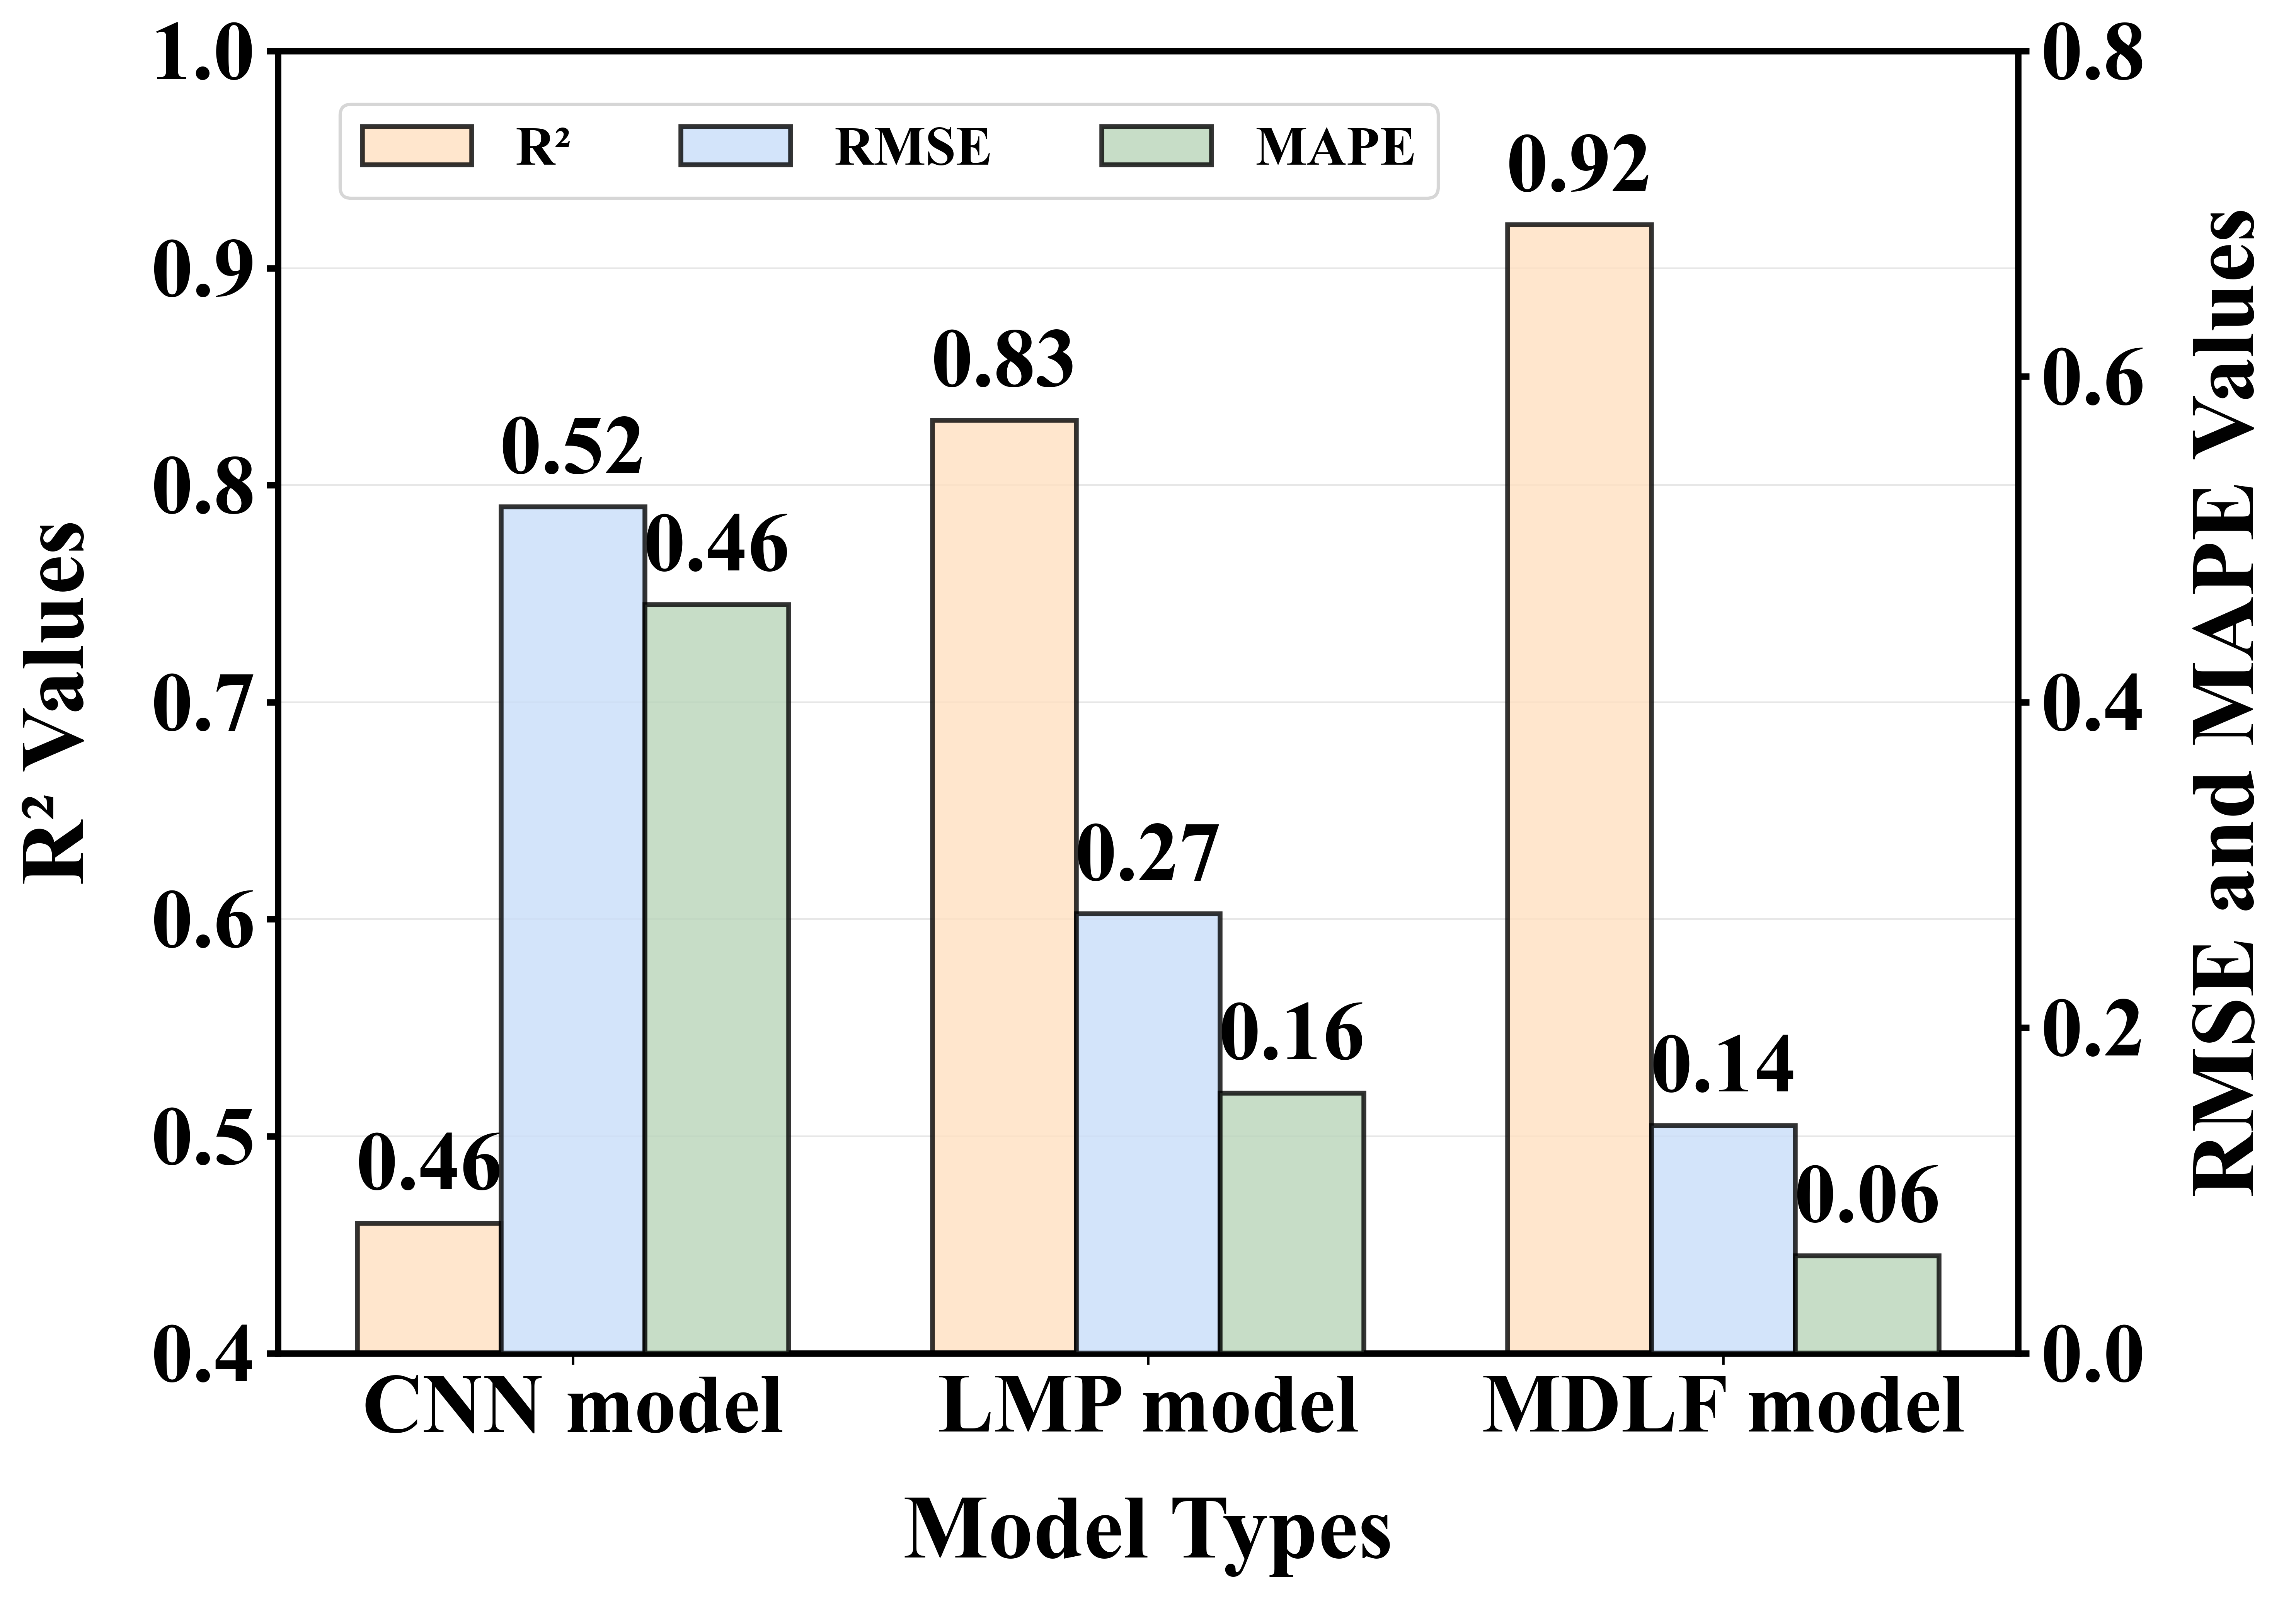

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 设置全局字体为新罗马并加粗
# ==========================================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'

def create_grouped_bar_chart():
    """创建带双纵坐标轴的分组柱状图 (Model Types 对比)"""
    
    # 数据定义
    groups = ['CNN model', 'LMP model', 'MDLF model']
    
    # 三个类别的数据
    r2_values = [0.46, 0.83, 0.92]      # R²值 - 使用左轴
    rmse_values = [0.52, 0.27, 0.14]    # RMSE值 - 使用右轴
    mape_values = [0.46, 0.16, 0.06]    # MAPE值 - 使用右轴
    
    # 设置柱状图的位置
    x = np.arange(len(groups))
    width = 0.25  # 柱子宽度
    
    # 创建图形和主坐标轴
    fig, ax1 = plt.subplots(figsize=(10, 7), dpi=600)
    
    # 创建右侧的第二个y轴
    ax2 = ax1.twinx()

    # 绘制R²柱状图（左轴）
    bars_r2 = ax1.bar(x - width, r2_values, width,
                      color='#FFE0C1', alpha=0.8,
                      edgecolor='black', linewidth=1.5,
                      label='R²')
    
    # 绘制RMSE柱状图（右轴）
    bars_rmse = ax2.bar(x, rmse_values, width,
                        color='#C9DEF9', alpha=0.8,
                        edgecolor='black', linewidth=1.5,
                        label='RMSE')
    
    # 绘制MAPE柱状图（右轴）
    bars_mape = ax2.bar(x + width, mape_values, width,
                        color='#b9d5ba', alpha=0.8,
                        edgecolor='black', linewidth=1.5,
                        label='MAPE')
    
    # ==========================================
    # 设置x轴标签（新罗马 + 加粗 + 字体大小）
    # ==========================================
    ax1.set_xticks(x)
    ax1.set_xticklabels(groups, fontsize=26, fontweight='bold')
    ax1.set_xlabel('Model Types', fontsize=28, fontweight='bold', labelpad=15)
    
    # 设置左y轴（R²）
    ax1.set_ylim(0.4, 1.0)
    ax1.set_ylabel('R² Values', fontsize=28, fontweight='bold', color='#000000', labelpad=15)
    y_ticks_left = np.arange(0.4, 1.1, 0.1)
    ax1.set_yticks(y_ticks_left)
    ax1.set_yticklabels([f'{y:.1f}' for y in y_ticks_left],
                       fontsize=26, fontweight='bold', color='#000000')
    ax1.tick_params(axis='y', labelcolor='#000000', width=2)
    
    # 设置右y轴（RMSE和MAPE）
    ax2.set_ylim(0.0, 0.6)
    ax2.set_ylabel('RMSE and MAPE Values', fontsize=28, fontweight='bold', color='#000000', labelpad=15)
    y_ticks_right = np.arange(0.0, 0.81, 0.2)
    ax2.set_yticks(y_ticks_right)
    ax2.set_yticklabels([f'{y:.1f}' for y in y_ticks_right],
                       fontsize=26, fontweight='bold', color='#000000')
    ax2.tick_params(axis='y', labelcolor='#000000', width=2)
    
    # 添加网格
    ax1.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    ax1.set_axisbelow(True)
    
    # 设置边框
    for spine in ax1.spines.values():
        spine.set_linewidth(2.0)
        spine.set_color('black')
    
    # 在每个柱子上添加数值标签
    def add_value_labels(bars, ax, size=24):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 5),
                       textcoords="offset points",
                       ha='center', va='bottom',
                       fontsize=size, fontweight='bold',
                       color='#000000')
    
    # 添加数值标签
    add_value_labels(bars_r2, ax1, size=26)
    add_value_labels(bars_rmse, ax2, size=26)
    add_value_labels(bars_mape, ax2, size=26)
    
    # 创建组合图例（新罗马 + 加粗）
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    leg = ax1.legend(lines1 + lines2, labels1 + labels2,
              loc='upper left', fontsize=17, frameon=True,
              bbox_to_anchor=(0.02, 0.98), ncol=3)
    
    for text in leg.get_texts():
        text.set_fontweight('bold')
    
    plt.tight_layout()
    return fig, ax1, ax2

# 运行示例
if __name__ == "__main__":
    fig1, ax1, ax2 = create_grouped_bar_chart()
    plt.savefig('Model_Comparison_Chart.png', dpi=600) # 保存为高分图片
    plt.show()

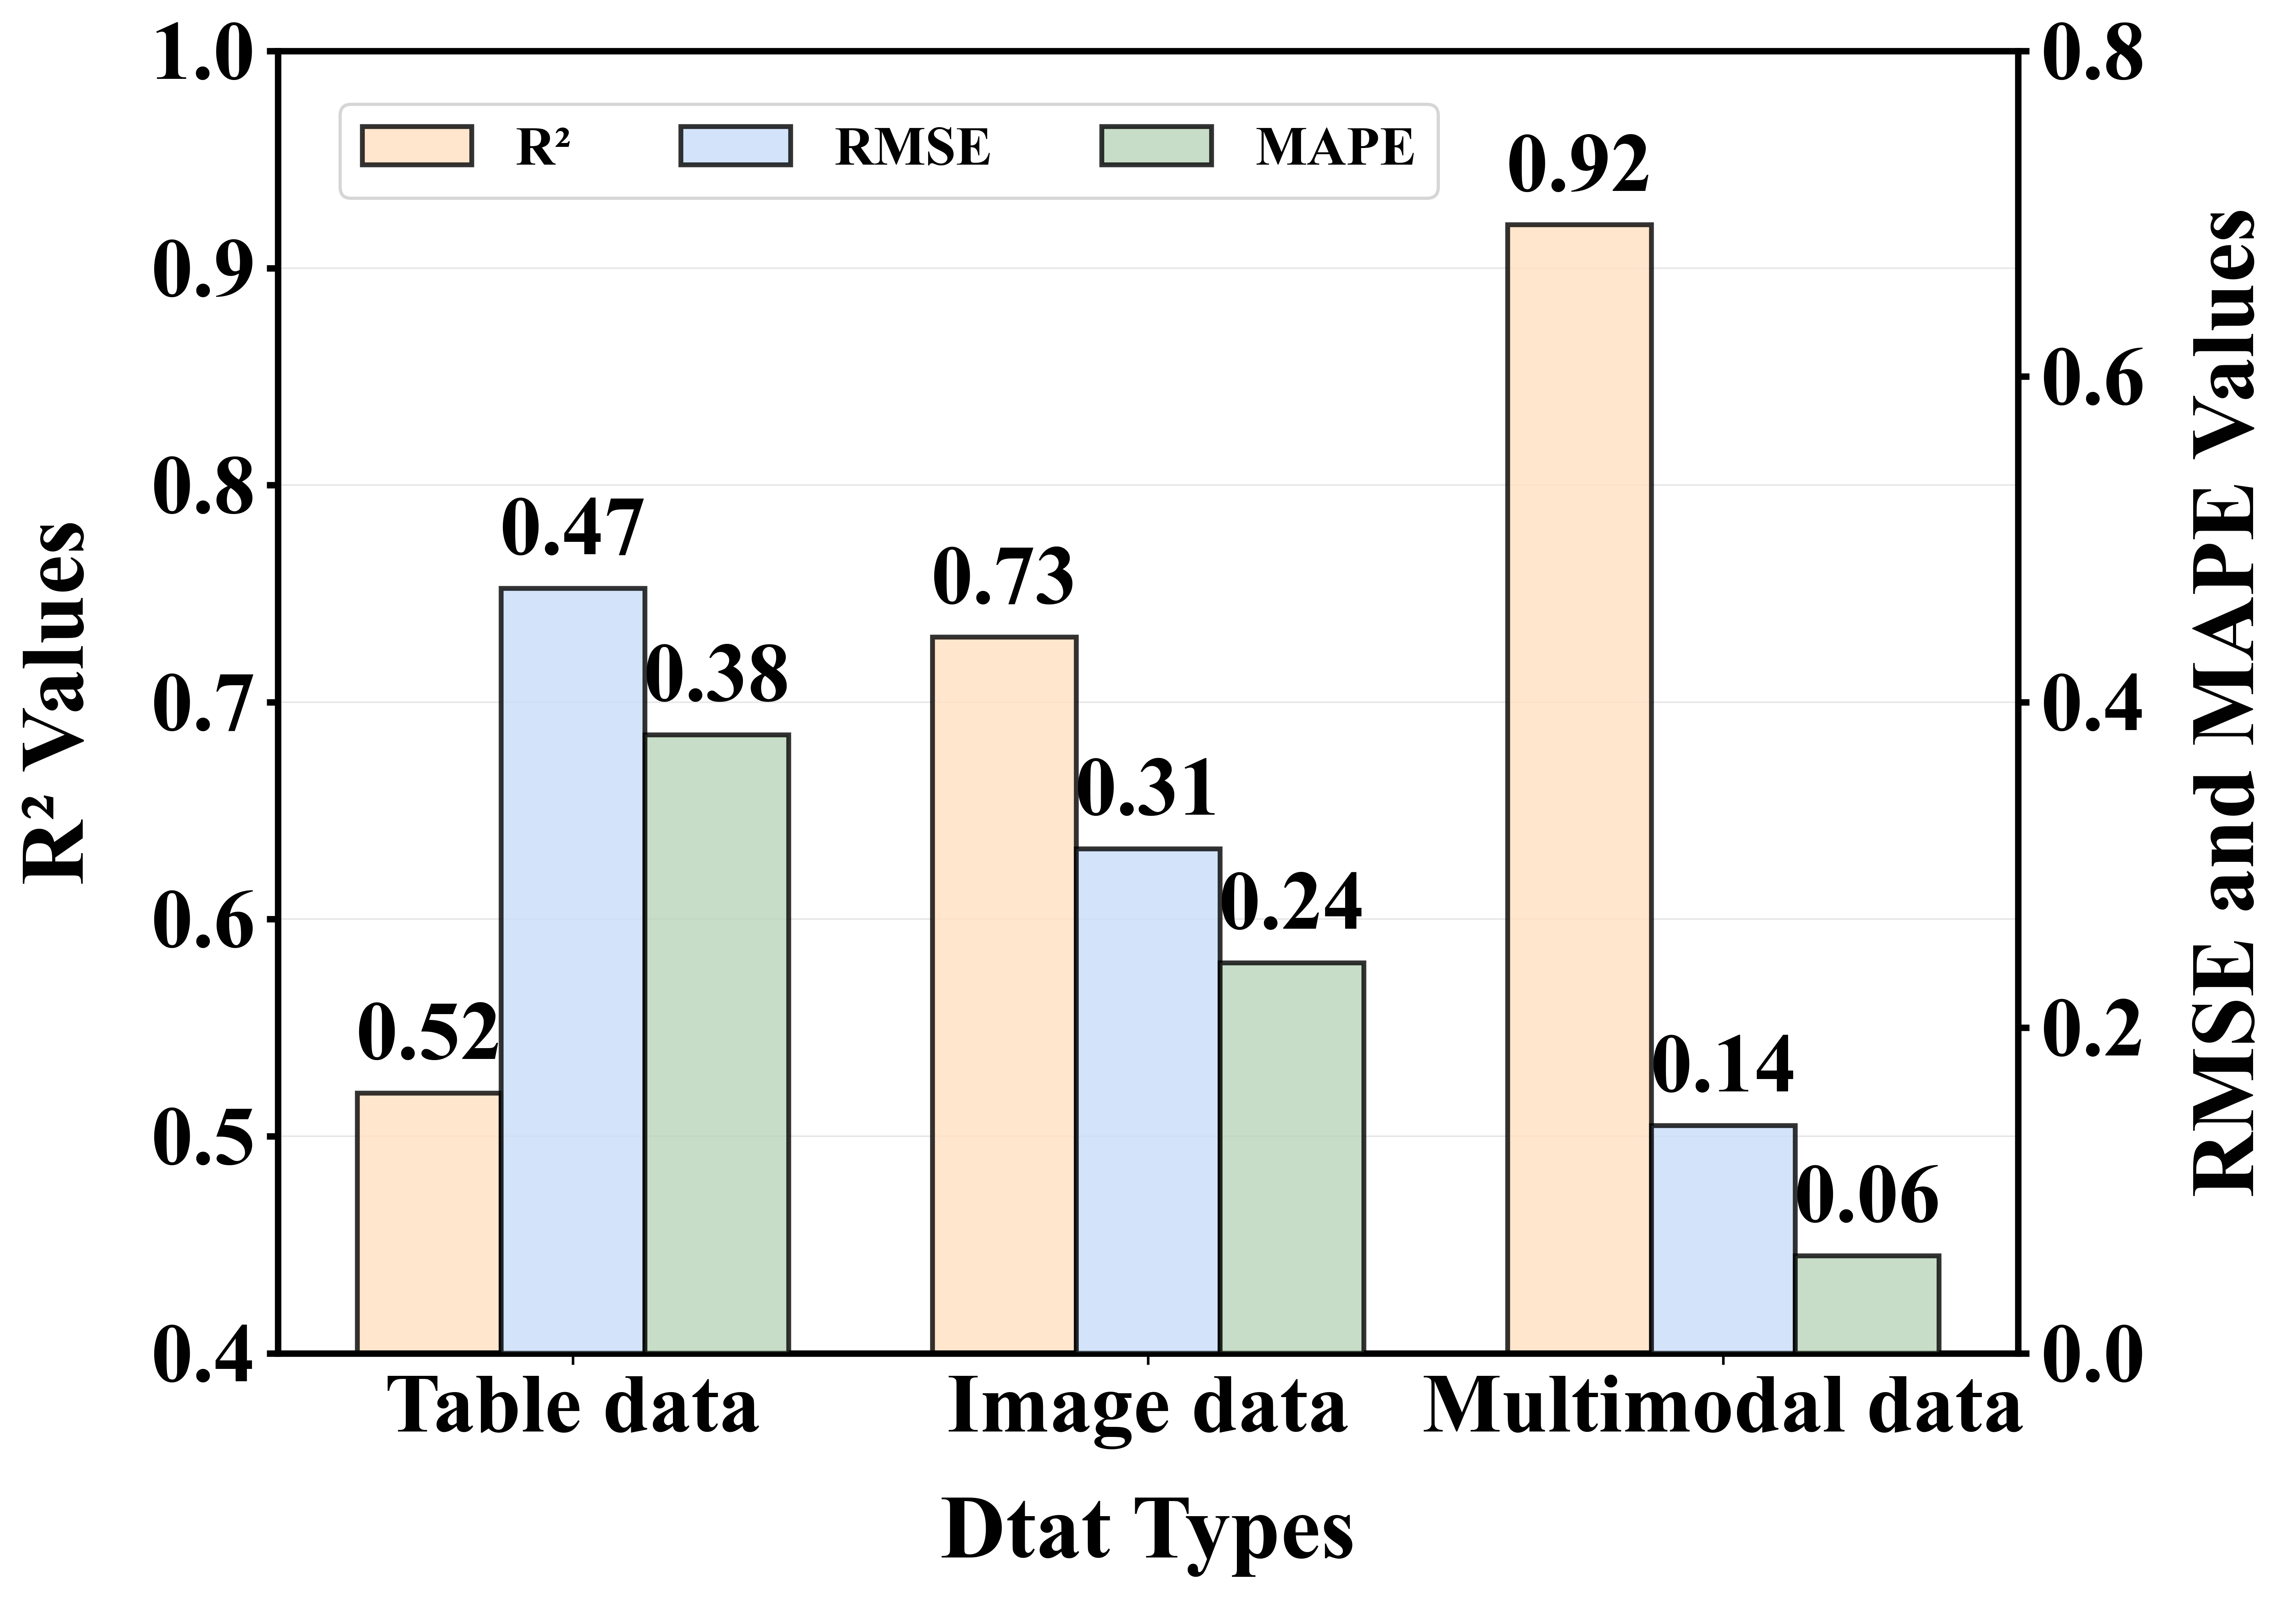

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 设置全局字体为新罗马并加粗
# ==========================================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'

def create_grouped_bar_chart():
    """创建带双纵坐标轴的分组柱状图 (Model Types 对比)"""
    
    # 数据定义
    groups = ['Table data', 'Image data', 'Multimodal data']
    
    # 三个类别的数据
    r2_values = [0.52,0.73,0.92]      # R²值 - 使用左轴
    rmse_values = [0.47,0.31,0.14]    # RMSE值 - 使用右轴
    mape_values = [0.38,0.24,0.06]    # MAPE值 - 使用右轴
    
    # 设置柱状图的位置
    x = np.arange(len(groups))
    width = 0.25  # 柱子宽度
    
    # 创建图形和主坐标轴
    fig, ax1 = plt.subplots(figsize=(10, 7), dpi=600)
    
    # 创建右侧的第二个y轴
    ax2 = ax1.twinx()

    # 绘制R²柱状图（左轴）
    bars_r2 = ax1.bar(x - width, r2_values, width,
                      color='#FFE0C1', alpha=0.8,
                      edgecolor='black', linewidth=1.5,
                      label='R²')
    
    # 绘制RMSE柱状图（右轴）
    bars_rmse = ax2.bar(x, rmse_values, width,
                        color='#C9DEF9', alpha=0.8,
                        edgecolor='black', linewidth=1.5,
                        label='RMSE')
    
    # 绘制MAPE柱状图（右轴）
    bars_mape = ax2.bar(x + width, mape_values, width,
                        color='#b9d5ba', alpha=0.8,
                        edgecolor='black', linewidth=1.5,
                        label='MAPE')
    
    # ==========================================
    # 设置x轴标签（新罗马 + 加粗 + 字体大小）
    # ==========================================
    ax1.set_xticks(x)
    ax1.set_xticklabels(groups, fontsize=26, fontweight='bold')
    ax1.set_xlabel('Dtat Types', fontsize=28, fontweight='bold', labelpad=15)
    
    # 设置左y轴（R²）
    ax1.set_ylim(0.4, 1.0)
    ax1.set_ylabel('R² Values', fontsize=28, fontweight='bold', color='#000000', labelpad=15)
    y_ticks_left = np.arange(0.4, 1.1, 0.1)
    ax1.set_yticks(y_ticks_left)
    ax1.set_yticklabels([f'{y:.1f}' for y in y_ticks_left],
                       fontsize=26, fontweight='bold', color='#000000')
    ax1.tick_params(axis='y', labelcolor='#000000', width=2)
    
    # 设置右y轴（RMSE和MAPE）
    ax2.set_ylim(0.0, 0.6)
    ax2.set_ylabel('RMSE and MAPE Values', fontsize=28, fontweight='bold', color='#000000', labelpad=15)
    y_ticks_right = np.arange(0.0, 0.81, 0.2)
    ax2.set_yticks(y_ticks_right)
    ax2.set_yticklabels([f'{y:.1f}' for y in y_ticks_right],
                       fontsize=26, fontweight='bold', color='#000000')
    ax2.tick_params(axis='y', labelcolor='#000000', width=2)
    
    # 添加网格
    ax1.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    ax1.set_axisbelow(True)
    
    # 设置边框
    for spine in ax1.spines.values():
        spine.set_linewidth(2.0)
        spine.set_color('black')
    
    # 在每个柱子上添加数值标签
    def add_value_labels(bars, ax, size=24):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 5),
                       textcoords="offset points",
                       ha='center', va='bottom',
                       fontsize=size, fontweight='bold',
                       color='#000000')
    
    # 添加数值标签
    add_value_labels(bars_r2, ax1, size=26)
    add_value_labels(bars_rmse, ax2, size=26)
    add_value_labels(bars_mape, ax2, size=26)
    
    # 创建组合图例（新罗马 + 加粗）
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    leg = ax1.legend(lines1 + lines2, labels1 + labels2,
              loc='upper left', fontsize=17, frameon=True,
              bbox_to_anchor=(0.02, 0.98), ncol=3)
    
    for text in leg.get_texts():
        text.set_fontweight('bold')
    
    plt.tight_layout()
    return fig, ax1, ax2

# 运行示例
if __name__ == "__main__":
    fig1, ax1, ax2 = create_grouped_bar_chart()
    plt.savefig('Model_Comparison_Chart.png', dpi=600) # 保存为高分图片
    plt.show()